# Week 14: 멀티모달 LLM(LMM) 실무 및 구조화 데이터 추출 실습

본 노트북은 멀티모달 LLM을 활용하여 이미지 데이터를 분석하고, 실무에서 사용할 수 있는 구조화된 데이터(Structured Output)를 추출한 뒤 이를 검증하는 실습을 진행합니다.

## 실습 목표
1. **Vision API 호출**: OpenAI `gpt-4o` 및 Google GenAI `gemini-2.5-flash`(또는 `gemini-1.5-flash`) 모델을 사용해 이미지를 분석합니다.
2. **구조화 데이터 추출(Structured Output)**: Pydantic을 활용하여 출력 스키마를 강제하고 데이터를 JSON 형태로 정형화합니다.
3. **데이터 검증(Data Validation)**: Pandera를 활용하여 추출된 데이터프레임의 비즈니스 규칙 준수 여부를 검증합니다.

## 1. 환경 설정 및 API 키 로드

실습에 필요한 라이브러리를 임포트하고 `.env` 파일로부터 API 키를 로드합니다.

In [1]:
import os
import base64
from PIL import Image
from io import BytesIO
from config import GOOGLE_AI_API_KEY, OPENAI_API_KEY, CONTENT_DIR


openai_api_key = OPENAI_API_KEY
gemini_api_key = GOOGLE_AI_API_KEY

print("OpenAI API Key Load:", "Success" if openai_api_key else "Fail")
print("Gemini API Key Load:", "Success" if gemini_api_key else "Fail")

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

# 실습에 활용할 이미지 경로 설정 (예: 루트 content 폴더의 샘플 활용)
image_path = CONTENT_DIR / "cat1.png"  # 적절한 로컬 이미지로 교체

OpenAI API Key Load: Success
Gemini API Key Load: Success


## 2. OpenAI GPT-4o Vision API 실습

OpenAI의 `gpt-4o` 모델을 사용하여 로컬 이미지를 분석하는 실습을 진행합니다.
이미지를 base64로 인코딩하여 API 페이로드에 포함시키는 표준 프로덕션 패턴을 사용합니다.

In [2]:
from openai import OpenAI

client = OpenAI(api_key=openai_api_key)

try:
    base64_image = encode_image(image_path)
    
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "이미지에 무엇이 보이나요? 자세히 묘사해주세요."},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{base64_image}"
                        }
                    }
                ]
            }
        ],
        max_tokens=300
    )

    print(response.choices[0].message.content)
except Exception as e:
    print("Error:", e)

이미지에는 세 마리의 새끼 고양이가 나란히 앉아 있습니다. 이 고양이들은 모두 얼굴과 몸에 털이 매우 풍성하고 귀엽습니다. 가운데 고양이는 털이 조금 더 밝은 색을 띄고 있으며, 양쪽의 두 고양이는 어두운 색의 털을 가지고 있습니다. 배경은 흰색으로 고양이들의 모습을 뚜렷하게 보여줍니다. 고양이들은 모두 카메라를 응시하고 있어 귀여움을 더하고 있습니다.


## 3. Google GenAI SDK를 활용한 Gemini 실습

Google의 최신 `google-genai` 라이브러리를 사용하여 이미지를 처리합니다. 
Pillow 객체를 직접 API의 contents 리스트에 전달할 수 있어 개발 생산성이 우수합니다.

In [2]:
from google import genai
from google.genai import types

# 공식 SDK 사용 방식
gemini_client = genai.Client(api_key=gemini_api_key)

try:
    img = Image.open(image_path)
    
    response = gemini_client.models.generate_content(
        model='gemma-4-31b-it',
        contents=['이 이미지의 주요 특징을 추출하고, 분석 결과를 설명해주세요.', img]
    )
    
    print(response.text)
except Exception as e:
    print("Error:", e)

제시된 이미지는 세 마리의 새끼 고양이를 포착한 흑백 사진입니다. 이 이미지의 주요 특징과 분석 결과는 다음과 같습니다.

### 1. 주요 특징 추출 (Feature Extraction)

*   **피사체:** 세 마리의 털이 풍성한 새끼 고양이.
*   **색상 구성:** 무채색(Grayscale/Black and White). 흰색 배경과 고양이들의 어두운/밝은 털색이 강한 대비를 이룹니다.
*   **구도:** 고양이 세 마리가 가로로 나란히 배치된 대칭적이고 안정적인 구도입니다.
*   **배경:** 아무런 장식이 없는 순백색의 스튜디오 배경으로, 시선이 오직 피사체(고양이)에게만 집중되도록 설계되었습니다.
*   **디테일:** 고양이들의 털 질감(fluffy texture), 반짝이는 눈망울, 작은 코와 입술 등 세밀한 묘사가 돋보입니다.

### 2. 분석 결과 설명 (Analysis)

**① 시각적 대비와 강조**
흑백 처리된 이미지는 색상의 방해 없이 **'형태'와 '질감'**에 집중하게 만듭니다. 특히 아주 밝은 배경과 고양이들의 짙은 털색이 대비되어, 고양이들의 외곽선(실루엣)이 매우 뚜렷하게 드러납니다.

**② 질감의 표현 (Texture)**
이 사진의 가장 큰 매력은 **털의 질감**입니다. 장모종으로 보이는 새끼 고양이들의 솜털 하나하나가 세밀하게 표현되어 있어, 시각적으로 매우 부드럽고 포근한 느낌을 줍니다.

**③ 정서적 분위기 (Mood)**
*   **순수함과 귀여움:** 정면을 응시하는 호기심 어린 눈빛과 작은 체구는 보는 이로 하여금 보호 본능과 애정을 느끼게 합니다.
*   **차분함:** 화려한 색상을 배제한 흑백 톤은 이미지에 고전적이고 차분하며 정돈된 분위기를 부여합니다.

**④ 촬영 기법적 측면**
피사체의 눈에 초점이 정확히 맞추어져 있어 생동감이 느껴지며, 하단에 살짝 드리워진 부드러운 그림자는 고양이들이 공간 속에 실제로 존재한다는 입체감을 부여합니다.

### [요약]
이 이미지는 **미니멀리즘적

## 4. Pydantic 및 Pandera를 활용한 구조화 데이터 추출 & 검증 (Production-Level)

실무에서는 LMM의 자유 분방한 텍스트 답변보다 특정 스키마에 맞춘 JSON 출력이 필수적입니다. 
여기서는 영수증이나 표 이미지 등에서 객체를 추출하여 Pydantic으로 스키마를 강제하고, Pandera로 무결성을 검증하는 구조를 실습합니다.

In [3]:
from pydantic import BaseModel, Field
import pandas as pd
import pandera as pa
from typing import List

# 1. Pydantic 모델 정의 (LMM이 준수해야 할 스키마)
class DetectedObject(BaseModel):
    label: str = Field(description="감지된 객체의 한글 명칭")
    confidence: float = Field(description="해당 객체가 존재할 확신도 (0.0 ~ 1.0)")
    coordinate_xywh: List[float] = Field(description="바운딩 박스 정규화 좌표 [x_min, y_min, width, height] (각 0.0~1.0 사이값)")

class ImageAnalysisResult(BaseModel):
    summary: str = Field(description="이미지 전체 요약")
    objects: List[DetectedObject] = Field(description="이미지 내에서 감지된 주요 객체 리스트")

# 2. Pandera 스키마 정의 (데이터 분석 단계에서의 무결성 검증)
pandera_schema = pa.DataFrameSchema({
    "label": pa.Column(str),
    "confidence": pa.Column(float, pa.Check.in_range(0.0, 1.0)),
    "x_min": pa.Column(float, pa.Check.in_range(0.0, 1.0)),
    "y_min": pa.Column(float, pa.Check.in_range(0.0, 1.0)),
    "width": pa.Column(float, pa.Check.in_range(0.0, 1.0)),
    "height": pa.Column(float, pa.Check.in_range(0.0, 1.0))
})

try:
    # structured output 요청 (Gemini 2.5/2.0 활용)
    response = gemini_client.models.generate_content(
        model='gemma-4-31b-it',
        contents=['다음 이미지를 분석하여 스키마 규격에 맞게 정보를 채워주세요.', img],
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=ImageAnalysisResult,
            temperature=0.1
        )
    )
    
    # JSON 결과 파싱
    import json
    raw_json = json.loads(response.text)
    print("=== API 추출 원본 JSON ===")
    print(json.dumps(raw_json, indent=2, ensure_ascii=False))
    
    # Pandera 검증을 위한 DataFrame 변환
    rows = []
    for obj in raw_json.get("objects", []):
        coords = obj.get("coordinate_xywh", [0.0, 0.0, 0.0, 0.0])
        rows.append({
            "label": obj.get("label"),
            "confidence": obj.get("confidence"),
            "x_min": coords[0],
            "y_min": coords[1],
            "width": coords[2],
            "height": coords[3]
        })
    
    df = pd.DataFrame(rows)
    
    print("\n=== 변환된 데이터프레임 ===")
    print(df)
    
    # Pandera 스키마 검증 수행
    validated_df = pandera_schema.validate(df)
    print("\n[Pandera 검증 완료] 데이터가 안정성 기준을 완벽하게 만족합니다.")
    
except Exception as e:
    print("Error or Validation Failed:", e)

/home/hong/project/ai-camp-note/.venv/lib/python3.13/site-packages/pandera/_pandas_deprecated.py:144: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


=== API 추출 원본 JSON ===
{
  "summary": "흰색 배경의 흑백 사진으로, 세 마리의 털이 많은 새끼 고양이들이 나란히 앉아 정면을 바라보고 있습니다.",
  "objects": [
    {
      "label": "새끼 고양이",
      "confidence": 0.99,
      "coordinate_xywh": [
        0.227,
        0.278,
        0.19,
        0.498
      ]
    },
    {
      "label": "새끼 고양이",
      "confidence": 0.99,
      "coordinate_xywh": [
        0.408,
        0.205,
        0.19,
        0.552
      ]
    },
    {
      "label": "새끼 고양이",
      "confidence": 0.99,
      "coordinate_xywh": [
        0.548,
        0.291,
        0.248,
        0.476
      ]
    }
  ]
}

=== 변환된 데이터프레임 ===
    label  confidence  x_min  y_min  width  height
0  새끼 고양이        0.99  0.227  0.278  0.190   0.498
1  새끼 고양이        0.99  0.408  0.205  0.190   0.552
2  새끼 고양이        0.99  0.548  0.291  0.248   0.476

[Pandera 검증 완료] 데이터가 안정성 기준을 완벽하게 만족합니다.


In [4]:
import os
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

import clip

device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)

In [5]:
image_path = CONTENT_DIR / "cat2.jpg"
classes = ["a person", "a car", "a dog", "a cat"]

img = Image.open(image_path)

image = preprocess(img).unsqueeze(0).to(device)
text = clip.tokenize(classes).to(device)

with torch.no_grad():
    logits_per_image, _ = model(image, text)
    print(logits_per_image)
    print("="*20)
    print(_)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]
    print("="*20)
    print(probs)

for label, prob in zip(classes, probs):
    print(f"{label}: {prob:.4f}")

prob_test = torch.tensor([0.0107,  0.0044, 0.9826, 0.0024])
classes = ["a person", "a car", "a dog", "a cat"]

# "a dog"
print(prob_test.argmax())
print(classes[prob_test.argmax()])

# unsqueeze는 텐서에 크기가 1인 차원을 하나 추가하는 함수

x1 = torch.tensor([1.0, 2.0, 3.0]) # x1은 1차원 텐서. 즉, 값이 3개 있는 벡터
print(x1)
print(x1.shape)

x2 = x1.unsqueeze(0)    # unsqueeze(0)은 0번 위치, 즉, 맨 앞에 차원 하나를 추가
print(x2)
print(x2.shape)

# 이게 필요한 이유는 딥러닝 모델들이 보통 입력을 배치 단위로 받기 때문.
# [3]은 데이터 1개처럼 보이지만,모델 입장에서는 "배치 차원"이 없음
# [1, 3]은 "샘플 1개 가 있고, 각 샘플은 값 3개를 가진다"는 뜻.

tensor([[18.0775, 17.7008, 19.7036, 23.4754]])
tensor([[18.0775],
        [17.7008],
        [19.7036],
        [23.4754]])
[0.00439125 0.00301306 0.02232542 0.9702702 ]
a person: 0.0044
a car: 0.0030
a dog: 0.0223
a cat: 0.9703
tensor(2)
a dog
tensor([1., 2., 3.])
torch.Size([3])
tensor([[1., 2., 3.]])
torch.Size([1, 3])


검색 대상 파일 리스트: ['/home/hong/project/ai-camp-note/content/en_sample.jpg', '/home/hong/project/ai-camp-note/content/example_img1.png', '/home/hong/project/ai-camp-note/content/glasses.png', '/home/hong/project/ai-camp-note/content/시험정보.png', '/home/hong/project/ai-camp-note/content/cat_test.png', '/home/hong/project/ai-camp-note/content/kakao_13.jpg', '/home/hong/project/ai-camp-note/content/pants.png', '/home/hong/project/ai-camp-note/content/cheer.jpg', '/home/hong/project/ai-camp-note/content/cat2.jpg', '/home/hong/project/ai-camp-note/content/masked_img.jpg', '/home/hong/project/ai-camp-note/content/new_example_gray.jpg', '/home/hong/project/ai-camp-note/content/business-card_640.jpg', '/home/hong/project/ai-camp-note/content/gnd.png', '/home/hong/project/ai-camp-note/content/mask_heart.jpg', '/home/hong/project/ai-camp-note/content/11.png', '/home/hong/project/ai-camp-note/content/냉장고.jpg', '/home/hong/project/ai-camp-note/content/saved_roi_img.jpg', '/home/hong/project/ai-camp-note/

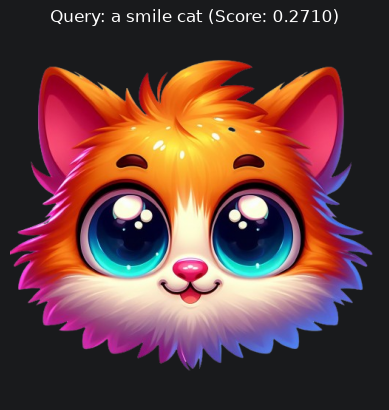

In [8]:
import os
import torch
from PIL import Image
import clip
import matplotlib.pyplot as plt

# 1. 장치 설정 및 모델 불러오기
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# 2. 검색 대상 폴더 및 이미지 목록 불러오기
image_folder = CONTENT_DIR
files = []
allow_extensions = ["jpg", "jpeg", "png"]

for file in os.listdir(image_folder):
    if file.split(".")[-1].lower() in allow_extensions:
        files.append(os.path.join(image_folder, file))
print("검색 대상 파일 리스트:", files)

# 3. 폴더 이미지 벡터화하기 (특징 추출)
image_features = []
for file in files:
    img = Image.open(file)
    # Ultralytics 버전의 preprocess 함수로 이미지 전처리 및 배치 차원(unsqueeze) 추가
    image_input = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        # 이미지 인코더를 통해 특징 추출 및 정규화
        feature = model.encode_image(image_input)
        feature /= feature.norm(dim=-1, keepdim=True)
        image_features.append(feature.cpu())

# 개별 이미지 텐서들을 하나의 행렬로 결합
image_features = torch.cat(image_features, dim=0)

# 4. 검색 쿼리 설정 및 텍સ્ટ 벡터화
query = "a smile cat"
top_k = 3

# clip.tokenize를 사용하여 텍스트 전처리
text_input = clip.tokenize([query]).to(device)

with torch.no_grad():
    # 텍스트 인코더를 통해 특징 추출 및 정규화
    text_feature = model.encode_text(text_input)
    text_feature /= text_feature.norm(dim=-1, keepdim=True)

# 5. 유사도 계산 (코사인 유사도)
# 두 벡터 모두 정규화되었으므로 행렬 곱(@) 연산으로 유사도 측정 가능
similarity = (image_features @ text_feature.cpu().T).squeeze(1)
top_indices = similarity.argsort(descending=True)[:top_k]

print("\n--- 검색 결과 ---")
print("각 이미지별 유사도 점수:", similarity.numpy())
print("유사도 높은 순 인덱스:", top_indices.numpy())

# 6. 가장 유사도가 높은 결과 시각화
best_match_idx = top_indices[0].item()
best_img = Image.open(files[best_match_idx])

plt.imshow(best_img)
plt.title(f"Query: {query} (Score: {similarity[best_match_idx]:.4f})")
plt.axis("off")
plt.show()

In [13]:
import os
import glob
import base64
from io import BytesIO
from PIL import Image

# 구글 공식 최신 SDK 로드
from google import genai
from google.genai import types

# LangChain 및 벡터 DB 구성 요소
from langchain_chroma import Chroma
from langchain_core.embeddings import Embeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda  # 👈 RunnableLambda 추가
from langchain_core.output_parsers import StrOutputParser

# 1. 경로 및 클라이언트 초기화
BASE_PATH = "./rag_data"  # 로컬 프로젝트 기준 폴더
CHROMA_DIR = os.path.join(BASE_PATH, "chroma")
FIGURES_DIR = os.path.join(BASE_PATH, "figures")

os.makedirs(CHROMA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Google GenAI 클라이언트 초기화 (환경 변수의 GEMINI_API_KEY를 자동으로 감지합니다)
ai_client = genai.Client(api_key=gemini_api_key)


# 2. 커스텀 LangChain 임베딩 클래스 정의 (Gemini Embedding 2 연동)
class GeminiEmbedding2(Embeddings):
    def __init__(self, model_name="gemini-embedding-2"):
        self.model_name = model_name

    def embed_documents(self, texts: list[str]) -> list[list[float]]:
        # gemini-embedding-2는 대량의 단일 일괄 처리를 위해 embed_content를 호출합니다.
        embeddings = []
        for text in texts:
            response = ai_client.models.embed_content(
                model=self.model_name,
                contents=text
            )
            # 단일 임베딩 벡터 값 추출
            embeddings.append(response.embeddings[0].values)
        return embeddings

    def embed_query(self, text: str) -> list[float]:
        response = ai_client.models.embed_content(
            model=self.model_name,
            contents=text
        )
        return response.embeddings[0].values


# 3. 이미지 도우미 함수 정의
def image_to_base64(image_path):
    """로컬 이미지를 DB 메타데이터 저장용 Base64 스트링으로 인코딩"""
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


def summarize_image_with_gemini(image_path):
    """Gemini를 사용해 이미지를 안전교육 관점에서 요약"""
    img = Image.open(image_path)

    prompt = "아래 이미지를 안전교육 및 화재대피 관점에서 주제 문구와 각 장면에 대해 주요 정보에 대한 손실없이 한국어로 요약해주세요."

    # 최신 SDK는 이미지 객체와 텍스트 프롬프트를 리스트로 묶어 간단히 전달합니다.
    response = ai_client.models.generate_content(
        model="gemma-4-31b-it", # 이미지 요약을 담당할 강력한 멀티모달 모델
        contents=[img, prompt]
    )
    return response.text


# 4. 벡터 DB 및 임베딩 설정
custom_embeddings = GeminiEmbedding2()

vectordb = Chroma(
    collection_name="multimodal_rag_genai",
    embedding_function=custom_embeddings,
    persist_directory=CHROMA_DIR
)


# 5. 이미지 데이터 파이프라인 (최초 1회 데이터 적재 시 사용)
def ingest_images_to_db():
    image_files = glob.glob(os.path.join(FIGURES_DIR, "*.jpg"))
    image_files = sorted(image_files)

    if not image_files:
        print(f"⚠️ {FIGURES_DIR} 폴더에 요약할 .jpg 파일이 없습니다. 이미지를 넣고 다시 구동해주세요.")
        return

    print(f"📦 총 {len(image_files)}개의 이미지 벡터화를 시작합니다...")
    for img_path in image_files:
        print(f"🔄 분석 중: {os.path.basename(img_path)}")
        b64_str = image_to_base64(img_path)
        summary = summarize_image_with_gemini(img_path)

        # 벡터 DB에 이미지 요약본 및 원본 메타데이터 적재
        vectordb.add_texts(
            texts=[summary],
            metadatas=[{"base64_image": b64_str, "image_path": img_path}]
        )
    print("✅ 모든 이미지가 'gemini-embedding-2'를 거쳐 ChromaDB에 적재되었습니다.")


# 6. DB 적재 데이터 확인용 출력 함수
def check_stored_data():
    collection_data = vectordb._collection.get()
    documents = collection_data.get('documents', [])
    metadatas = collection_data.get('metadatas', [])

    print(f"\n===== 현재 DB 저장 데이터 확인 (총 {len(documents)}개) =====")
    for idx, (doc, meta) in enumerate(zip(documents, metadatas)):
        print(f"[{idx + 1}] 파일 경로: {meta.get('image_path')}")
        print(f"    요약본 내용: {doc[:60]}...")
        print("-" * 50)


# 7. Gemma 4 기반 LCEL RAG 체인 구성하기
# 구글 오피셜 API 엔드포인트의 gemma-4-31b-it를 연동하기 위해 커스텀 LLM wrapper를 구성하거나,
# SDK의 generate_content 인터페이스를 체인 파이프라인에 바인딩합니다.
def ask_gemma_4(inputs: dict):
    context = inputs["context"]
    question = inputs["question"]

    # 1. 모델의 행동 지침은 시스템 인스트럭션으로 격리
    system_instruction = (
        "주어진 참고 자료(Context)만을 바탕으로 사용자의 질문(Question)에 친절하고 정확하게 답해주세요.\n"
        "자료에 없는 내용은 절대 추측하거나 지어내어 답하지 마세요."
    )

    # 2. 순수 데이터 영역만 유저 콘텐츠로 구성
    user_content = f"""[참고 자료]
{context}

[사용자 질문]
{question}"""

    # google-genai SDK 규격에 맞게 호출
    response = ai_client.models.generate_content(
        model="gemma-4-31b-it",
        contents=user_content,
        config=types.GenerateContentConfig(
            system_instruction=system_instruction,  # 👈 분리 적용
            temperature=0.1  # 결정론적 답변을 위해 온도를 조금 더 낮춤
        )
    )
    return response.text

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

retriever = vectordb.as_retriever(search_kwargs={"k": 1})

# LangChain LCEL 파이프라인 연결

qa_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | RunnableLambda(ask_gemma_4)  # 👈 일반 함수를 RunnableLambda로 감싸줍니다!
)

# 8. 메인 실행 흐름
if __name__ == "__main__":
    # 💡 [중요] 최초 실행 시 폴더 안의 이미지를 분석해서 집어넣으려면 아래 주석을 푸세요!
    # ingest_images_to_db()

    # DB 상태 출력
    check_stored_data()

    # 테스트 질문 던지기
    query = "소화기 사용법이나 화재 대피 시 대처 요령에 대해 설명해줘."
    print(f"\n💬 질문: {query}")

    # 컨텍스트 조회를 위한 검색 수행
    matched_docs = retriever.invoke(query)

    # RAG 체인 실행
    answer = qa_chain.invoke(query)

    print("\n🤖 gemma-4-31b-it 답변:")
    print(answer)

    print("\n🗺️ 답변의 근거가 된 로컬 이미지 출처:")
    for doc in matched_docs:
        print(f"- 파일 위치: {doc.metadata['image_path']}")
        # 로컬 환경에서 이미지를 직접 팝업 창으로 확인하고 싶다면 아래 주석을 푸세요.
        # img = Image.open(BytesIO(base64.b64decode(doc.metadata['base64_image'])))
        # img.show()


===== 현재 DB 저장 데이터 확인 (총 0개) =====

💬 질문: 소화기 사용법이나 화재 대피 시 대처 요령에 대해 설명해줘.


ServerError: 500 INTERNAL. {'error': {'code': 500, 'message': 'Internal error encountered.', 'status': 'INTERNAL'}}